<a href="https://colab.research.google.com/github/BharathraajNagarajan/TriClass-Lab-Logistic-Regression-Multi-Class-SVM-Benchmark/blob/main/TriClass_Lab_Logistic_Regression_Multi_Class_SVM_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()

Saving mnist_all.mat to mnist_all.mat


In [6]:
import numpy as np
from scipy.io import loadmat
from scipy.optimize import minimize

def preprocess():
    """
     Input:
     Although this function doesn't have any input, you are required to load
     the MNIST data set from file 'mnist_all.mat'.

     Output:
     train_data: matrix of training set. Each row of train_data contains
       feature vector of a image
     train_label: vector of label corresponding to each image in the training
       set
     validation_data: matrix of training set. Each row of validation_data
       contains feature vector of a image
     validation_label: vector of label corresponding to each image in the
       training set
     test_data: matrix of training set. Each row of test_data contains
       feature vector of a image
     test_label: vector of label corresponding to each image in the testing
       set
    """

    mat = loadmat('mnist_all.mat')  # loads the MAT object as a Dictionary

    n_feature = mat.get("train1").shape[1]
    n_sample = 0
    for i in range(10):
        n_sample = n_sample + mat.get("train" + str(i)).shape[0]
    n_validation = 1000
    n_train = n_sample - 10 * n_validation

    # Construct validation data
    validation_data = np.zeros((10 * n_validation, n_feature))
    for i in range(10):
        validation_data[i * n_validation:(i + 1) * n_validation, :] = mat.get("train" + str(i))[0:n_validation, :]

    # Construct validation label
    validation_label = np.ones((10 * n_validation, 1))
    for i in range(10):
        validation_label[i * n_validation:(i + 1) * n_validation, :] = i * np.ones((n_validation, 1))

    # Construct training data and label
    train_data = np.zeros((n_train, n_feature))
    train_label = np.zeros((n_train, 1))
    temp = 0
    for i in range(10):
        size_i = mat.get("train" + str(i)).shape[0]
        train_data[temp:temp + size_i - n_validation, :] = mat.get("train" + str(i))[n_validation:size_i, :]
        train_label[temp:temp + size_i - n_validation, :] = i * np.ones((size_i - n_validation, 1))
        temp = temp + size_i - n_validation

    # Construct test data and label
    n_test = 0
    for i in range(10):
        n_test = n_test + mat.get("test" + str(i)).shape[0]
    test_data = np.zeros((n_test, n_feature))
    test_label = np.zeros((n_test, 1))
    temp = 0
    for i in range(10):
        size_i = mat.get("test" + str(i)).shape[0]
        test_data[temp:temp + size_i, :] = mat.get("test" + str(i))
        test_label[temp:temp + size_i, :] = i * np.ones((size_i, 1))
        temp = temp + size_i

    # Delete features which don't provide any useful information for classifiers
    sigma = np.std(train_data, axis=0)
    index = np.array([])
    for i in range(n_feature):
        if (sigma[i] > 0.001):
            index = np.append(index, [i])
    train_data = train_data[:, index.astype(int)]
    validation_data = validation_data[:, index.astype(int)]
    test_data = test_data[:, index.astype(int)]

    # Scale data to 0 and 1
    train_data /= 255.0
    validation_data /= 255.0
    test_data /= 255.0

    return train_data, train_label, validation_data, validation_label, test_data, test_label

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def blrObjFunction(initialWeights, *args):
    """
    blrObjFunction computes 2-class Logistic Regression error function and
    its gradient.

    Input:
        initialWeights: the weight vector (w_k) of size (D + 1) x 1
        train_data: the data matrix of size N x D
        labeli: the label vector (y_k) of size N x 1 where each entry can be either 0 or 1 representing the label of corresponding feature vector

    Output:
        error: the scalar value of error function of 2-class logistic regression
        error_grad: the vector of size (D+1) x 1 representing the gradient of
                    error function
    """
    train_data, labeli = args

    n_data = train_data.shape[0]
    n_features = train_data.shape[1]
    error = 0
    error_grad = np.zeros((n_features + 1, 1))

    ##################
    # YOUR CODE HERE #
    ##################
    # HINT: Do not forget to add the bias term to your input data

    X = np.hstack((np.ones((n_data, 1)), train_data))
    y = labeli
    w = initialWeights.reshape((-1, 1))

    theta = sigmoid(np.dot(X, w))
    error = -1 * np.sum(y * np.log(theta) + (1 - y) * np.log(1 - theta)) / n_data
    error_grad = np.dot(X.T, (theta - y)) / n_data

    return error, error_grad.flatten()


def blrPredict(W, data):
    """
     blrObjFunction predicts the label of data given the data and parameter W
     of Logistic Regression

     Input:
         W: the matrix of weight of size (D + 1) x 10. Each column is the weight
         vector of a Logistic Regression classifier.
         X: the data matrix of size N x D

     Output:
         label: vector of size N x 1 representing the predicted label of
         corresponding feature vector given in data matrix

    """
    label = np.zeros((data.shape[0], 1))

    ##################
    # YOUR CODE HERE #
    ##################
    # HINT: Do not forget to add the bias term to your input data

    n_data = data.shape[0]
    X = np.hstack((np.ones((n_data, 1)), data))
    z = np.dot(X, W)
    probs = sigmoid(z)
    label = np.argmax(probs, axis=1).reshape((-1, 1))
    return label

In [7]:
"""
Script for Logistic Regression
"""
train_data, train_label, validation_data, validation_label, test_data, test_label = preprocess()

# number of classes
n_class = 10

# number of training samples
n_train = train_data.shape[0]

# number of features
n_feature = train_data.shape[1]

Y = np.zeros((n_train, n_class))
for i in range(n_class):
    Y[:, i] = (train_label == i).astype(int).ravel()

# Logistic Regression with Gradient Descent
W = np.zeros((n_feature + 1, n_class))
initialWeights = np.zeros((n_feature + 1, ))
opts = {'maxiter': 100}
for i in range(n_class):
    labeli = Y[:, i].reshape(n_train, 1)
    args = (train_data, labeli)
    nn_params = minimize(blrObjFunction, initialWeights, jac=True, args=args, method='CG', options=opts)
    W[:, i] = nn_params.x.reshape((n_feature + 1,))

# Find the accuracy on Training Dataset
predicted_label = blrPredict(W, train_data)
print('\n Training set Accuracy:' + str(100 * np.mean((predicted_label == train_label).astype(float))) + '%')

# Find the accuracy on Validation Dataset
predicted_label = blrPredict(W, validation_data)
print('\n Validation set Accuracy:' + str(100 * np.mean((predicted_label == validation_label).astype(float))) + '%')

# Find the accuracy on Testing Dataset
predicted_label = blrPredict(W, test_data)
print('\n Testing set Accuracy:' + str(100 * np.mean((predicted_label == test_label).astype(float))) + '%')



 Training set Accuracy:92.66799999999999%

 Validation set Accuracy:91.45%

 Testing set Accuracy:91.99000000000001%



Linear kernel
  train : 97.29%
  valid : 93.64%
  test  : 93.78%

RBF  (gamma = 1)
  train : 100.00%
  valid : 15.48%
  test  : 17.14%

RBF  (gamma = default)
  train : 98.98%
  valid : 97.89%
  test  : 97.87%

RBF (default gamma) – accuracy as C changes:
  C =   1  |  train  98.98%   valid  97.89%
  C =  10  |  train  99.99%   valid  98.45%
  C =  20  |  train 100.00%   valid  98.44%
  C =  30  |  train 100.00%   valid  98.44%
  C =  40  |  train 100.00%   valid  98.44%
  C =  50  |  train 100.00%   valid  98.44%
  C =  60  |  train 100.00%   valid  98.44%
  C =  70  |  train 100.00%   valid  98.44%
  C =  80  |  train 100.00%   valid  98.44%
  C =  90  |  train 100.00%   valid  98.44%
  C = 100  |  train 100.00%   valid  98.44%


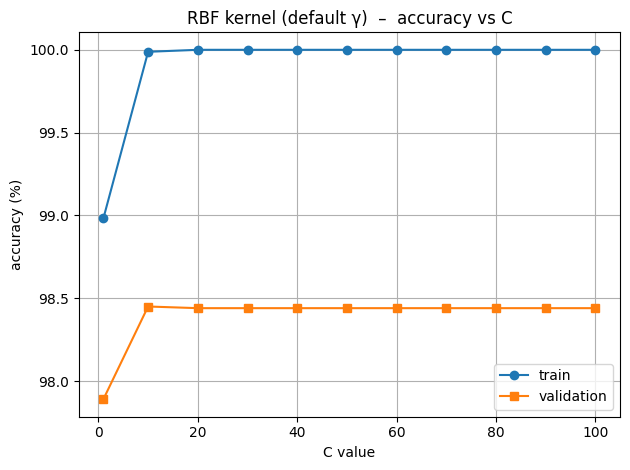

In [8]:
# -------------------------------------------
#   SVM experiments on MNIST features
#   (linear kernel + three RBF scenarios)
# -------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

def show_scores(name, clf, Xtr, ytr, Xval, yval, Xtst, ytst):
    print(f'\n{name}')
    print('  train :', f'{accuracy_score(ytr,  clf.predict(Xtr))*100:.2f}%')
    print('  valid :', f'{accuracy_score(yval, clf.predict(Xval))*100:.2f}%')
    print('  test  :', f'{accuracy_score(ytst, clf.predict(Xtst))*100:.2f}%')

# ---------------------------------------------------------------
# 1. linear kernel  (all other params = default)
# ---------------------------------------------------------------
svm_lin = SVC(kernel='linear')
svm_lin.fit(train_data, train_label.ravel())
show_scores('Linear kernel', svm_lin,
            train_data, train_label,
            validation_data, validation_label,
            test_data,    test_label)

# ---------------------------------------------------------------
# 2. RBF kernel with gamma = 1
# ---------------------------------------------------------------
svm_rbf_g1 = SVC(kernel='rbf', gamma=1)
svm_rbf_g1.fit(train_data, train_label.ravel())
show_scores('RBF  (gamma = 1)', svm_rbf_g1,
            train_data, train_label,
            validation_data, validation_label,
            test_data,    test_label)

# ---------------------------------------------------------------
# 3. RBF kernel with default gamma ('scale')
# ---------------------------------------------------------------
svm_rbf_def = SVC(kernel='rbf')
svm_rbf_def.fit(train_data, train_label.ravel())
show_scores('RBF  (gamma = default)', svm_rbf_def,
            train_data, train_label,
            validation_data, validation_label,
            test_data,    test_label)

# ---------------------------------------------------------------
# 4. RBF kernel (default gamma) while C varies
#    C  = 1, 10, 20, ..., 100
# ---------------------------------------------------------------
C_values       = [1] + list(range(10, 101, 10))
acc_train      = []
acc_valid      = []

print('\nRBF (default gamma) – accuracy as C changes:')
for C in C_values:
    clf = SVC(kernel='rbf', C=C)        # gamma still at default
    clf.fit(train_data, train_label.ravel())

    tr_acc = accuracy_score(train_label,       clf.predict(train_data)) * 100
    va_acc = accuracy_score(validation_label, clf.predict(validation_data)) * 100

    acc_train.append(tr_acc)
    acc_valid.append(va_acc)

    print(f'  C = {C:3d}  |  train {tr_acc:6.2f}%   valid {va_acc:6.2f}%')

# quick plot
plt.plot(C_values, acc_train, 'o-', label='train')
plt.plot(C_values, acc_valid, 's-', label='validation')
plt.xlabel('C value')
plt.ylabel('accuracy (%)')
plt.title('RBF kernel (default γ)  –  accuracy vs C')
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()


In [8]:
def mlrObjFunction(params, *args):
    """
    mlrObjFunction computes multi-class Logistic Regression error function and
    its gradient.

    Input:
        initialWeights_b: the weight vector of size (D + 1) x 10
        train_data: the data matrix of size N x D
        labeli: the label vector of size N x 1 where each entry can be either 0 or 1
                representing the label of corresponding feature vector

    Output:
        error: the scalar value of error function of multi-class logistic regression
        error_grad: the vector of size (D+1) x 10 representing the gradient of
                    error function
    """
    train_data, labeli = args
    n_data = train_data.shape[0]
    n_feature = train_data.shape[1]


    ##################
    # YOUR CODE HERE #
    ##################
    # HINT: Do not forget to add the bias term to your input data

    train_data, label_mat = args        # label_mat is the N×10 one-hot Y
    N, D   = train_data.shape
    K      = label_mat.shape[1]         # should be 10

    # ------------ reshape weights ---------------
    if params.ndim == 1:                # minimise may flatten x
        W = params.reshape((D + 1, K))
    else:
        W = params                      # already (D+1) × K

    # ------------ add bias column ---------------
    X = np.hstack((np.ones((N, 1)), train_data))   # N × (D+1)

    # ------------ forward pass  (soft-max) -------
    scores   = X @ W                                   # N × K
    scores  -= scores.max(axis=1, keepdims=True)       # numeric stability
    exp_s    = np.exp(scores)
    probs    = exp_s / exp_s.sum(axis=1, keepdims=True)

    # ------------ cross-entropy loss -------------
    error = -np.sum(label_mat * np.log(probs)) / N

    # ------------ gradient -----------------------
    grad_mat = X.T @ (probs - label_mat) / N          # (D+1) × K

    return error, grad_mat.flatten()                  # flatten for minimise


def mlrPredict(W, data):
    """
     mlrObjFunction predicts the label of data given the data and parameter W
     of Logistic Regression

     Input:
         W: the matrix of weight of size (D + 1) x 10. Each column is the weight
         vector of a Logistic Regression classifier.
         X: the data matrix of size N x D

     Output:
         label: vector of size N x 1 representing the predicted label of
         corresponding feature vector given in data matrix

    """

    ##################
    # YOUR CODE HERE #
    ##################
    # HINT: Do not forget to add the bias term to your input data

    N = data.shape[0]
    Xb = np.hstack((np.ones((N, 1)), data))           # add bias
    scores = Xb @ W
    scores -= scores.max(axis=1, keepdims=True)       # stability
    exp_s   = np.exp(scores)
    probs   = exp_s / exp_s.sum(axis=1, keepdims=True)
    return np.argmax(probs, axis=1).reshape(-1, 1)

In [9]:
"""
Script for Extra Credit Part
"""
# FOR EXTRA CREDIT ONLY

W_b = np.zeros((n_feature + 1, n_class))
initialWeights_b = np.zeros(((n_feature + 1)* n_class))
opts_b = {'maxiter': 100}

args_b = (train_data, Y)
nn_params = minimize(mlrObjFunction, initialWeights_b, jac=True, args=args_b, method='CG', options=opts_b)
W_b = nn_params.x.reshape((n_feature + 1, n_class))

# Find the accuracy on Training Dataset
predicted_label_b = mlrPredict(W_b, train_data)
print('\n Training set Accuracy:' + str(100 * np.mean((predicted_label_b == train_label).astype(float))) + '%')

# Find the accuracy on Validation Dataset
predicted_label_b = mlrPredict(W_b, validation_data)
print('\n Validation set Accuracy:' + str(100 * np.mean((predicted_label_b == validation_label).astype(float))) + '%')

# Find the accuracy on Testing Dataset
predicted_label_b = mlrPredict(W_b, test_data)
print('\n Testing set Accuracy:' + str(100 * np.mean((predicted_label_b == test_label).astype(float))) + '%')


 Training set Accuracy:93.448%

 Validation set Accuracy:92.47999999999999%

 Testing set Accuracy:92.55%
